In [60]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import rasterio as rio

import matplotlib.pyplot as plt

from hydra.conf import HydraConf
from omegaconf import OmegaConf, DictConfig
from hydra import initialize,compose
from hydra.utils import instantiate, call

from fuelex.utils.aef import dequantize
from fuelex.retrieval import get_gee_chip

FM40_LABELS = [
    91, 92, 93, 98, 99,
    101, 102, 103, 104, 105, 106, 107, 108, 109,
    121, 122, 123, 124,
    141, 142, 143, 144, 145, 146, 147, 148, 149,
    161, 162, 163, 164, 165,
    181, 182, 183, 184, 185, 186, 187, 188, 189,
    201, 202, 203, 204,
]

In [45]:
source_coop_path = Path('/home/rdemilt/redsky/fuelex/data/fuelex_dataset/Southern_Appalachians')
gee_path = Path('/mnt/data/rdemilt/fuelex/Southern_Appalachians')

year = 2024

source_coop_tiles = list(source_coop_path.glob('AEF*.tif'))
aef_scenes = [str(path).split('_')[-1][5:-4]for path in source_coop_tiles]
sample_scenes = np.random.permutation(aef_scenes)[0:5]

In [46]:
sample_batch = []
sample_gee_batch = []
fbfm40_batch = []
for scene in sample_scenes:
    fp = source_coop_path / f'AEF_{year}_Scene{scene}.tif'
    arr = dequantize(rio.open(fp).read())
    sample_batch.append(arr)

    fp = gee_path / f'AEF_{year}_SCENE{scene}.tif'
    arr = rio.open(fp).read()
    c, h, w = arr.shape
    center_h = h // 2
    center_w = w // 2
    radius = 128 // 2
    arr = arr[:,center_h-radius:center_h+radius,center_w-radius:center_w+radius]

    sample_gee_batch.append(arr)

    fp = gee_path / f'FBFM40_{year}_Scene{scene}.tif'
    arr = rio.open(fp).read(1)
    fbfm40_batch.append(arr)
sample_batch = np.stack(sample_batch,axis=0)
sample_gee_batch = np.stack(sample_gee_batch,axis=0)
fbfm40_batch = np.stack(fbfm40_batch,axis=0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32781237..0.21413302].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.31009611687812383..0.22145328719723184].


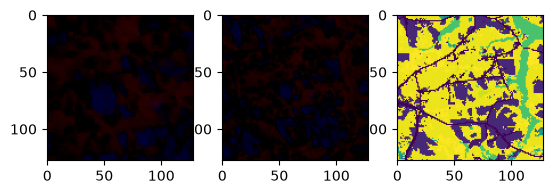

In [47]:
fig,axs = plt.subplots(nrows=1,ncols=3)

random_3_bands = np.random.uniform(0,64,size=3).astype(int)
axs[0].imshow(np.transpose(sample_gee_batch[2][random_3_bands],axes=(1,2,0)))

axs[1].imshow(np.transpose(sample_batch[2][random_3_bands],axes=(1,2,0)))

axs[2].imshow(fbfm40_batch[2])

plt.show()

In [49]:
import os
import torch
from fuelex.utils import get_best_model_ckpt_path
from fuelex.engine.train import model_factory

device='cpu'


exp_dir = Path('/home/rdemilt/redsky/fuelex/output/20260930_102220_3e760a_seg_segformer_fbfm40_Southern_Appalachians_2024_128px')
cfg_path = exp_dir / 'configs' / 'config.yaml'
cfg = OmegaConf.load(cfg_path)

final_model_ckpt_path = get_best_model_ckpt_path(exp_dir)

model_dict = torch.load(final_model_ckpt_path, map_location=device, weights_only=False)
model = model_factory(cfg)

model_name = os.path.basename(final_model_ckpt_path).split(".")[0]
if "model" in model_dict:
    model.load_state_dict(model_dict["model"])
else:
        model.load_state_dict(model_dict)

In [ ]:
dropped_labels = cfg.dataset.dropped_labels

valid_labels = [label for label in FM40_LABELS if label not in dropped_labels]
label_map = np.vectorize(dict(zip(np.arange(len(valid_labels)),valid_labels)).get)

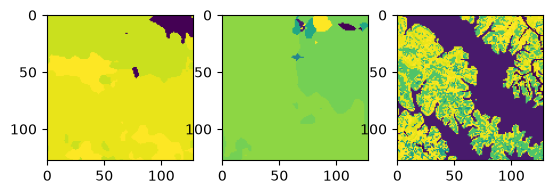

In [ ]:
fig,axs = plt.subplots(nrows=1,ncols=3)
with torch.no_grad():
    source_coop_logits = model(torch.from_numpy(sample_batch.astype(np.float64)).float())
    source_coop_preds = torch.argmax(torch.softmax(source_coop_logits,dim=1),dim=1).numpy()


    gee_logits = model(torch.from_numpy(sample_gee_batch.astype(np.float64)).float())
    gee_preds = torch.argmax(torch.softmax(gee_logits,dim=1),dim=1).numpy()

gt = fbfm40_batch[1]

source_coop_example = label_map(source_coop_preds[1])
source_coop_example[~np.isin(gt,valid_labels)] = 91
gee_example = label_map(gee_preds[1])
gee_example[~np.isin(gt,valid_labels)] = 91
axs[0].imshow(source_coop_example)

axs[1].imshow(gee_example)

axs[2].imshow(gt)
plt.show()


In [68]:
label_map(source_coop_preds)

array([[[186, 186, 186, ..., 182, 182, 182],
        [186, 186, 186, ..., 182, 182, 182],
        [186, 186, 186, ..., 182, 182, 182],
        ...,
        [102, 102, 102, ..., 186, 186, 186],
        [102, 102, 102, ..., 186, 186, 186],
        [102, 102, 102, ..., 186, 186, 186]],

       [[182, 182, 182, ..., 102, 182, 182],
        [182, 182, 182, ..., 102, 102, 182],
        [182, 182, 182, ..., 102, 102, 182],
        ...,
        [186, 186, 186, ..., 186, 186, 186],
        [186, 186, 186, ..., 186, 186, 186],
        [186, 186, 186, ..., 186, 186, 186]],

       [[182, 182, 182, ..., 186, 102, 102],
        [182, 182, 182, ..., 186, 102, 102],
        [182, 182, 182, ..., 186, 186, 102],
        ...,
        [189, 102, 102, ..., 122, 122, 122],
        [189, 102, 102, ..., 122, 122, 122],
        [189, 102, 102, ..., 122, 122, 122]],

       [[186, 186, 186, ..., 102, 102, 102],
        [186, 186, 186, ..., 102, 102, 102],
        [186, 186, 186, ..., 102, 102, 102],
        ..